In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Are NFL Scouting Combine Metrics Meaningful Predictors of Quarterback Performance?
### DATASCI 151 Final Project Spring 2026
**Group Members:** Nicholas Huang [2627522],

---

## Introduction

The NFL relies on the NFL Combine, a week-long event where top collegiate football players perform a series of athletic and cognitive tests in front of teams scouts, as one of the primary ways to discern player skill and draft value. For quarterbacks, one of the most valuable positions in the game, the combine is a chance to showcase the necessary physical and processing skills that may ensure them a spot in the league. These tests include the 40-yard dash, measuring straight-line speed, vertical jump and 3-cone drill, measuring agility and explosiveness, the 20-yard shuttle, measuring short-bursts of speeds, and the Wonderlic Personnel Test, measuring coginitive ability. Teams scouts watch prospective players complete these tests which then informs their decisions on if and when they should select them in the NFL Draft. The central question motivating this project is: **do combine measurements actually predict how well a quarterback performs in real NFL games?**

Using a combination of datasets from the **NFL Play Statistics dataset** from Kaggle, an open-source data sharing platform, we first calculate three career performance statistics for each quarterback: completion percentage, touchdown-to-interception ratio, and passing yards per game. We then merge these statistics with each player's combine testing results and draft statistics to examine the correlations between combine metrics and on-field performance. Our results indicate that [FILL IN]

## Data Description

In [ ]:
import pandas as pd #Importing Libraries
import numpy as np
import matplotlib.pyplot as plt

df_passer = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/passer.csv') #Importing Data
df_combine = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/combine.csv')
df_draft = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/draft.csv')
df_gp = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/gameParticipation.csv')

print("Passer") #Generating stats for dataframe length and unique observations
print("Number of rows:", len(df_passer))
print("Unique playerIds:", df_passer["playerId"].nunique())
print("Unique playIds:", df_passer["playId"].nunique())

print("\nCombine")
print("Number of rows:", len(df_combine))
print("Unique playerIds:", df_combine["playerId"].nunique())
print("Unique positions:", df_combine["combinePosition"].nunique())

print("\nDraft")
print("Number of rows:", len(df_draft))
print("Unique playerIds:", df_draft["playerId"].nunique())
print("Unique draft years:", df_draft["draft"].nunique())
print("Unique rounds:", df_draft["round"].nunique())

print("\nGameParticipation")
print("Number of rows:", len(df_gp))
print("Unique playerIds:", df_gp["playerId"].nunique())
print("Unique gameIds:", df_gp["gameId"].nunique())

Passer
Number of rows: 397265
Unique playerIds: 755
Unique playIds: 397265

Combine
Number of rows: 10080
Unique playerIds: 10078
Unique positions: 26

Draft
Number of rows: 12140
Unique playerIds: 12119
Unique draft years: 43
Unique rounds: 12

GameParticipation
Number of rows: 423185
Unique playerIds: 5827
Unique gameIds: 995


From the twenty available tables in the entire datset, we selected four for our analysis. The first, **`df_passer`** contains one row per pass attempt for every quarterback across the 2004–2019 NFL seasons, containing around 397,000 individual attempts, recording the outcome of each throw.  **`df_combine`** contains the combine testing results for all players, 10,080 unique players, who have participated in the event since the late 1980s. **`df_draft`** records the draft year, round, and pick number for all drafted players, consisting of 12,140 players. **`df_gp`** logs each player's appearance in each game, which we use to count the number of games each quarterback played in order to compute yards per game.

### Merging Data

To merge our data, we first aggregated the `df_passer` play-by-play table into one row per player with career totals. We also join `gameParticipation` to obtain each QB's total games played utilizing inner join. Second, we merge the `combine` and `draft` tables on `playerId`, also on inner join, and keep only quarterbacks. Finally, we join the combine+draft table with the passer statistics, again on `playerId`, to give us a single table with one row per QB that we can conduct analysis on.

In [6]:
df_passer['pass_yards'] = df_passer['passLength'] * df_passer['passComp'] #Isolating only completed passes

qb_stats = df_passer.groupby('playerId').agg(attempts = ('passAtt', 'sum'), #Aggregating QB stats for each unique player
                                        completions = ('passComp', 'sum'),
                                        touchdowns = ('passTd', 'sum'),
                                        interceptions = ('passInt', 'sum'),
                                        total_yards = ('pass_yards','sum')).reset_index()

qb_games = (df_gp[df_gp['position'] == 'QB'].groupby(by = 'playerId')['gameId'].nunique()) #Counting games played per unique player

qb_stats = qb_stats.merge(qb_games, on='playerId', how='inner') #Merging games played and QB stats on inner, to preserve only players in QB stats

In [12]:
combine = df_combine
draft = df_draft

combine_draft = pd.merge(left = combine, right = draft, how = "inner", on = "playerId")

combine_draft = combine_draft.query("combinePosition == 'QB'")

### Cleaning Data

Our data required minimal cleaning. For `qb_stats`, we first examined the shape, data types, and unique values of each column. We used an inner join when merging the aggregated passer data with game participation counts, which excluded the 538 quarterbacks who appeared in `passer` but had no matching record in `gameParticipation`. We then used `query()` to filter out quarterbacks with fewer than 100 career pass attempts, as their career averages would not be representative of sustained NFL performance. Next we cleaned `combine_draft`. After our merge and query of combine + draft data, we narrowed our number of QBs to just 339. We then dropped all columns that were not of use to us during this analysis. We additionally found that a number of columns were at least half filled with missing values, and decided to drop said columns in order to maintain a stronger sample size.

In [13]:
n_rows, n_cols = qb_stats.shape #Computing stats for dataframe
print("# of rows:", n_rows)
print("# of columns:", n_cols)
print()
print(qb_stats.dtypes)
print()

print("Sample of games_played values:", pd.unique(qb_stats["gameId"])[:10])

qb_stats = qb_stats.query("attempts >= 100") #Only keeping players with over 100 passes

qb_stats['comp_pct'] = (qb_stats['completions'] / qb_stats['attempts'] * 100).round(2) #Computing QB stats of interest
qb_stats['td_int_ratio'] = (qb_stats['touchdowns'] / (qb_stats['interceptions'] + 1)).round(2)
qb_stats["yards_per_game"] = (qb_stats["total_yards"]  / qb_stats["gameId"]).round(2)

print("# of rows after cleaning:", len(qb_stats))
print()
print("Nulls remaining:")
print(qb_stats.isnull().sum())

# of rows: 167
# of columns: 10

playerId            int64
attempts            int64
completions         int64
touchdowns          int64
interceptions       int64
total_yards         int64
gameId              int64
comp_pct          float64
td_int_ratio      float64
yards_per_game    float64
dtype: object

Sample of games_played values: [20  7 61 14 49 34 12 19  1 45]
# of rows after cleaning: 167

Nulls remaining:
playerId          0
attempts          0
completions       0
touchdowns        0
interceptions     0
total_yards       0
gameId            0
comp_pct          0
td_int_ratio      0
yards_per_game    0
dtype: int64


In [14]:
print("# of QBs:", len(combine_draft))

# Drop unused columns
combine_draft = combine_draft.drop(columns = ["combineId_x", "nameFirst_x", "nameLast_x", 
                                              "collegeId_x", "nflId_x", "college_x", "heightInches_x", 
                                              "weight_x", "playerProfileUrl_x", "homeCity_x", "homeState_x", 
                                              "homeCountry_x", "hsCity_x", "highSchool_x", "hsState_x", 
                                              "hsCountry_x", "draftTeam", "teamId", "nameFirst_y", 
                                              "nameLast_y", "nameFull_y", "collegeId_y", "nflId_y", 
                                              "combineId_y", "college_y", "heightInches_y", "weight_y", 
                                              "dob_y", "playerProfileUrl_y", "homeCity_y", "homeState_y", 
                                              "homeCountry_y", "highSchool_y", "hsCity_y", "hsState_y", 
                                              "hsCountry_y", "ageAtDraft_y", "position_y"])

print(combine_draft.isnull().sum())
combine_draft = combine_draft.drop(columns = ["combineHand", "combineArm", "combineBench", "combine60ydShuttle"])

# of QBs: 339
playerId                0
combineYear             0
combinePosition         0
combineHeight           0
combineWeight           0
combineHand           240
nameFull_x              0
position_x              0
dob_x                   0
ageAtDraft_x            0
combineArm            249
combine40yd            43
combineVert            65
combineBench          322
combineShuttle         79
combineBroad           67
combine3cone          157
combine60ydShuttle    339
combineWonderlic      186
draft                   0
round                  11
pick                    0
draftTradeValue         0
dtype: int64


### Descriptive Statistics

The table below summarizes the three computed performance metrics and the five combine measurements we will use in our analysis. Combine metrics are shown for all QBs who have a recorded value.

In [ ]:
INSERT CODE FOR DESCRIPTIVE STATISTICS

: 

: 

: 

The correlation matrix below shows correlation coefficients between all numeric columns in our `combine_draft` dataset. We want to study which combine events or player atrtributes best correlate to the round they are picked. Better players are often picked earlier on in the draft, so we would expect negative correlation between how skilled a player is and the round in which they are picked. For example, there is a slight negative correlation (~0.353) between weight and round picked - meaning heavier quarterbacks are drafted slightly earlier than lighter ones on average. Perhaps heavier quarterbacks are more valuable.

In [15]:
display(combine_draft.corr(numeric_only = True).round(4))

,playerId,combineYear,combineHeight,combineWeight,ageAtDraft_x,combine40yd,combineVert,combineShuttle,combineBroad,combine3cone,combineWonderlic,draft,round,pick,draftTradeValue
playerId,1.0000,1.0000,0.1938,0.4222,-0.0355,-0.2513,0.2238,-0.2195,0.3176,-0.4274,0.1582,1.0000,-0.3223,-0.2118,0.1313
combineYear,1.0000,1.0000,0.1940,0.4224,-0.0357,-0.2515,0.2241,-0.2196,0.3178,-0.4277,0.1582,1.0000,-0.3232,-0.2127,0.1319
combineHeight,0.1938,0.1940,1.0000,0.6146,-0.0405,0.2330,-0.1267,0.1931,-0.0344,0.0767,0.1210,0.1940,-0.2555,-0.2314,0.1789
combineWeight,0.4222,0.4224,0.6146,1.0000,-0.1350,0.0157,0.1150,-0.0038,0.1297,-0.0533,0.0271,0.4224,-0.3530,-0.2951,0.2497
ageAtDraft_x,-0.0355,-0.0357,-0.0405,-0.1350,1.0000,0.1560,-0.1403,-0.0366,-0.2149,0.0639,-0.0245,-0.0357,0.2339,0.2621,-0.3282
combine40yd,-0.2513,-0.2515,0.2330,0.0157,0.1560,1.0000,-0.6929,0.5084,-0.6713,0.4669,0.1711,-0.2515,0.2624,0.2397,-0.2448
combineVert,0.2238,0.2241,-0.1267,0.1150,-0.1403,-0.6929,1.0000,-0.5300,0.7420,-0.3487,-0.0900,0.2241,-0.3337,-0.2955,0.2192
combineShuttle,-0.2195,-0.2196,0.1931,-0.0038,-0.0366,0.5084,-0.5300,1.0000,-0.4298,0.5285,-0.1128,-0.2196,0.2407,0.2030,-0.1108
combineBroad,0.3176,0.3178,-0.0344,0.1297,-0.2149,-0.6713,0.7420,-0.4298,1.0000,-0.4842,-0.1374,0.3178,-0.3047,-0.3028,0.2746
combine3cone,-0.4274,-0.4277,0.0767,-0.0533,0.0639,0.4669,-0.3487,0.5285,-0.4842,1.0000,-0.1811,-0.4277,0.2740,0.2663,-0.2597


Not only do we want to assess the strenghts of these relationships, but we want to visualize the relationships themselves. Below, scatterplots with lines of best fit show how player attributes or combine metrics can make them more valuable and get drafted earlier:

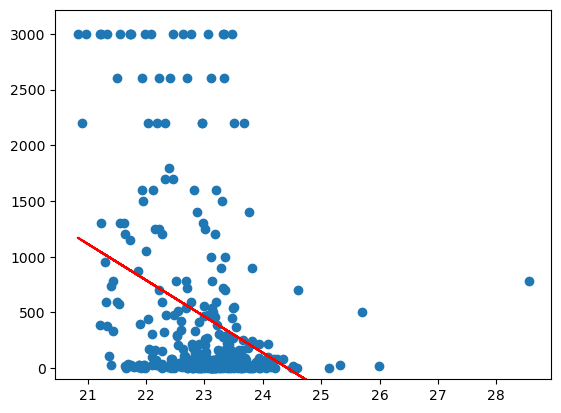

In [29]:
model = smf.ols(formula = "draftTradeValue ~ ageAtDraft_x", data = combine_draft)
coeffs = model.fit().params

a = coeffs["Intercept"]
b = coeffs["ageAtDraft_x"]

predicted_round = np.array(combine_draft["ageAtDraft_x"])
predicted_round = (b * predicted_round) + a

plt.scatter(combine_draft["ageAtDraft_x"], combine_draft["draftTradeValue"])
plt.plot(combine_draft["ageAtDraft_x"], predicted_round, color = "red")
plt.ylim(-100)
plt.show()

---
## Results

### Correlation Between Combine Metrics and QB Performance

In [ ]:
INSERT CODE FOR GENERATING CORRELATION AND SUMMARY TABLES

: 

: 

: 

**Interpretation:** 

INSERT INTERPRETATION OF DATA

---
## Discussion

INSERT DISCUSSION OF DATA